# AI-Powered Global Data & AI Job Market Intelligence




## 1. Introduction

Over the past decade, the demand for professionals in data science, artificial intelligence, and advanced analytics has increased significantly across global labor markets. Organizations across industries rely on data-driven decision making, resulting in growing demand for professionals such as Data Scientists, Machine Learning Engineers, Data Analysts, and AI Engineers.

However, the global market for these roles varies widely across countries, experience levels, and organizational structures. Salaries, employment types, remote work opportunities, and demand patterns differ between major technology hubs and emerging digital economies.

Understanding these patterns is important for professionals, companies, and policymakers seeking to navigate the rapidly evolving global AI and data talent landscape.

This project develops a Global Data & AI Job Market Intelligence System using data analytics and machine learning techniques to identify trends in salary distribution, job roles, experience levels, and geographic patterns within the global data and AI labor market.

## 2. Project Objectives

### The main objectives of this project are:

1: Analyze global salary trends for Data & AI professionals

2: Compare compensation patterns across countries

3: Examine how experience level influences salary outcomes

4: Analyze remote work distribution across job roles

5: Identify the highest-paying roles within the Data & AI sector

6: Develop a machine learning model to predict salaries based on job characteristics

## 3. Research Questions
### This study aims to answer the following questions:

1: Which countries offer the highest salaries for Data & AI professionals?

2: How does experience level influence compensation?

3: Which job roles command the highest salaries?

4: What proportion of jobs are remote versus on-site?

5: Can salary be predicted using machine learning techniques?

## 4. Dataset Description
The primary dataset used in this project is the Data Science Job Salaries dataset, obtained from Kaggle.

The dataset contains global job market data related to Data & AI roles.

### Key Variables

| Variable | Description |
|--------|-------------|
| work_year | Year the salary was recorded |
| experience_level | Level of professional experience |
| employment_type | Type of job (full-time, part-time, contract) |
| job_title | Role title |
| salary_in_usd | Salary standardized to USD |
| company_location | Country where the company operates |
| remote_ratio | Percentage of remote work |
| company_size | Size of the company |

## 5. Methodology
The project follows a structured data analytics pipeline consisting of the following stages:

1: Data Loading

2: Data Inspection

3: Data Cleaning

4: Feature Engineering

5: Exploratory Data Analysis (EDA)

6: Data Visualization

7: Machine Learning Modeling

8: Model Evaluation

9: Insight Generation

## 6. Data Loading

In this section, the dataset is imported into the analysis environment using Python.

The dataset is loaded using the pandas library, which provides powerful tools for data manipulation and analysis.

After loading the dataset, the first few rows are displayed to verify that the data has been successfully imported.

Expected outcome:
- Dataset successfully loaded
- First rows displayed for inspection

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("ds_salaries.csv")

# Display first rows
df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 7. Data Inspection

Before performing any analysis, it is important to understand the structure of the dataset.

This step helps identify:

- the number of observations in the dataset
- the available variables
- data types of each variable
- potential missing values
- general statistical properties of the data

Understanding these characteristics ensures that the dataset is suitable for further analysis and helps determine the necessary data cleaning steps.

In [3]:
# number of rows and columns
df.shape

(607, 12)

### Observations from Data Inspection

The dataset contains **607 observations and 12 variables**, providing information about salaries for Data and AI related roles across different countries.

The dataset includes both **numerical variables** (such as salary values and remote work ratio) and **categorical variables** (such as job title, experience level, and company size).

There are **no missing values in the dataset**, which simplifies the data preparation process. However, the dataset includes an unnecessary column (`Unnamed: 0`) that appears to represent an index column created during data export.

This column will be removed during the data cleaning stage.

In [4]:
# list all columns
df.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='object')

In [6]:
# Dataset Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          607 non-null    int64 
 1   work_year           607 non-null    int64 
 2   experience_level    607 non-null    object
 3   employment_type     607 non-null    object
 4   job_title           607 non-null    object
 5   salary              607 non-null    int64 
 6   salary_currency     607 non-null    object
 7   salary_in_usd       607 non-null    int64 
 8   employee_residence  607 non-null    object
 9   remote_ratio        607 non-null    int64 
 10  company_location    607 non-null    object
 11  company_size        607 non-null    object
dtypes: int64(5), object(7)
memory usage: 57.0+ KB


In [7]:
# Statistical Summary
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


## 8. Data Cleaning

Before performing analysis, the dataset must be cleaned to ensure accuracy and consistency.

The cleaning process includes:

- removing unnecessary columns
- checking for duplicate records
- verifying missing values
- preparing the dataset for analysis

These steps ensure that the dataset is reliable and suitable for further analysis.

In [8]:
# remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [9]:
# check for missing values
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [10]:
# check duplicates
df.duplicated().sum()

42

In [11]:
# drop duplicates
df = df.drop_duplicates()

In [12]:
df.shape

(565, 11)

### Data Cleaning Outcome

The dataset was inspected and cleaned to remove unnecessary variables and ensure data quality.

The redundant index column was removed, and the dataset was checked for missing values and duplicate records.

After these cleaning steps, the dataset is ready for feature engineering and exploratory analysis.

## 9. Feature Engineering

Feature engineering involves transforming raw variables into more meaningful and interpretable features that improve analytical clarity and model performance.

Several variables in the dataset use abbreviated codes that are not immediately interpretable. Therefore, these variables will be transformed into descriptive labels.

The transformations performed in this section include:

- Converting experience level codes into readable categories
- Converting company size codes into descriptive labels
- Converting remote work ratio into categorical groups

These transformations will improve interpretability during exploratory analysis and machine learning modeling.

In [13]:
df["experience_level"] = df["experience_level"].replace({
    "EN": "Entry",
    "MI": "Mid",
    "SE": "Senior",
    "EX": "Executive"
})

df["experience_level"].value_counts()

Senior       243
Mid          208
Entry         88
Executive     26
Name: experience_level, dtype: int64

In [14]:
df["company_size"] = df["company_size"].replace({
    "S": "Small",
    "M": "Medium",
    "L": "Large"
})

df["company_size"].value_counts()

Medium    290
Large     193
Small      82
Name: company_size, dtype: int64

In [15]:
df["remote_type"] = df["remote_ratio"].map({
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
})

df["remote_type"].value_counts()

Fully Remote    346
On-site         121
Hybrid           98
Name: remote_type, dtype: int64

In [16]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,remote_type
0,2020,Mid,FT,Data Scientist,70000,EUR,79833,DE,0,DE,Large,On-site
1,2020,Senior,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,Small,On-site
2,2020,Senior,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,Medium,Hybrid
3,2020,Mid,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,Small,On-site
4,2020,Senior,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,Large,Hybrid


### Feature Engineering Outcome

Several categorical variables were transformed into more interpretable labels.

Experience levels and company sizes were converted from abbreviated codes into descriptive categories. Additionally, a new feature called `remote_type` was created to classify job roles as on-site, hybrid, or fully remote.

These transformations improve the readability of the dataset and will support clearer exploratory analysis and visualization.

## 10. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to examine the dataset and identify patterns, relationships, and trends.

This stage helps answer key research questions and provides insights into the structure of the global Data & AI job market.

The following analyses will be performed:

1. Salary distribution analysis  
2. Salary comparison by experience level  
3. Highest paying job roles  
4. Geographic distribution of jobs  
5. Remote work distribution

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 10.1 Salary Distribution

Understanding the distribution of salaries helps identify the overall pay structure within the Data & AI job market.

This analysis highlights whether salaries are evenly distributed or concentrated within certain ranges.

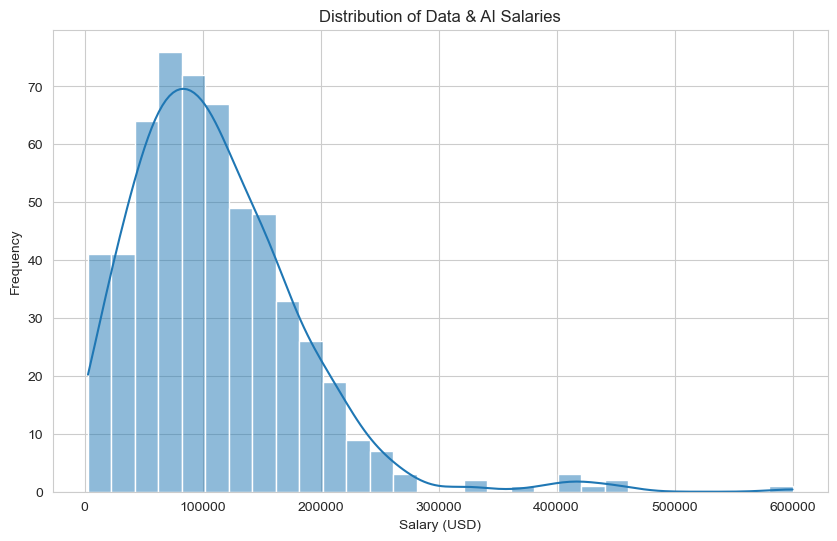

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df["salary_in_usd"], bins=30, kde=True)

plt.title("Distribution of Data & AI Salaries")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The salary distribution for Data and AI roles shows a right-skewed pattern, meaning most professionals earn salaries within a moderate range while a small number earn significantly higher salaries.

The majority of salaries appear to fall between approximately **$50,000 and $150,000**, indicating that this range represents the typical compensation for many data-related roles.

A few extreme values above **$300,000** are visible, suggesting the presence of high-level leadership or specialized technical roles such as principal engineers, directors, or senior executives.

#### 10.2 Salary by Experience Level

Experience level is expected to be a major determinant of salary in the Data & AI job market.

This analysis compares average salary across different experience levels.

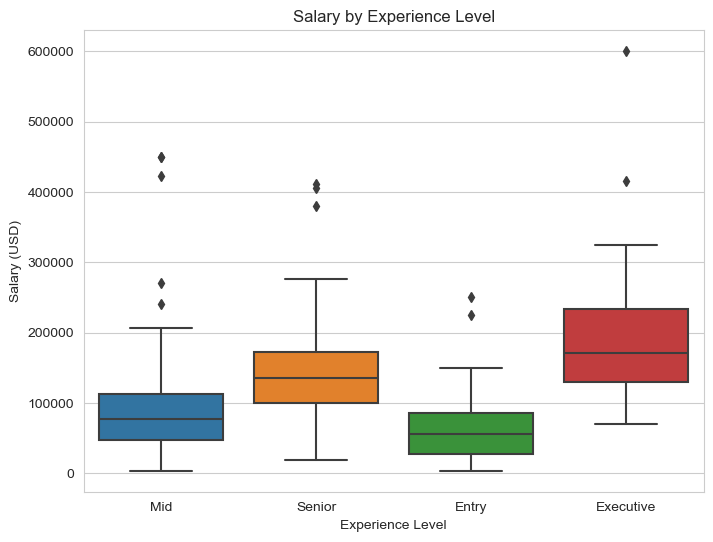

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(x="experience_level", y="salary_in_usd", data=df)

plt.title("Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")

plt.show()

### Interpretation

The analysis shows a clear relationship between experience level and salary. Entry-level professionals earn the lowest salaries, while senior and executive professionals earn significantly higher compensation.

Executive roles demonstrate the highest salary range and variability, suggesting that compensation at this level depends heavily on factors such as leadership responsibility, company size, and strategic importance.

Mid-level professionals represent a large portion of the workforce, with salaries concentrated around the middle salary ranges.

#### 10.3 Highest Paying Job Roles

Different job titles within the Data & AI ecosystem command different compensation levels.

This analysis identifies the roles with the highest average salaries.

In [20]:
top_roles = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

top_roles

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64

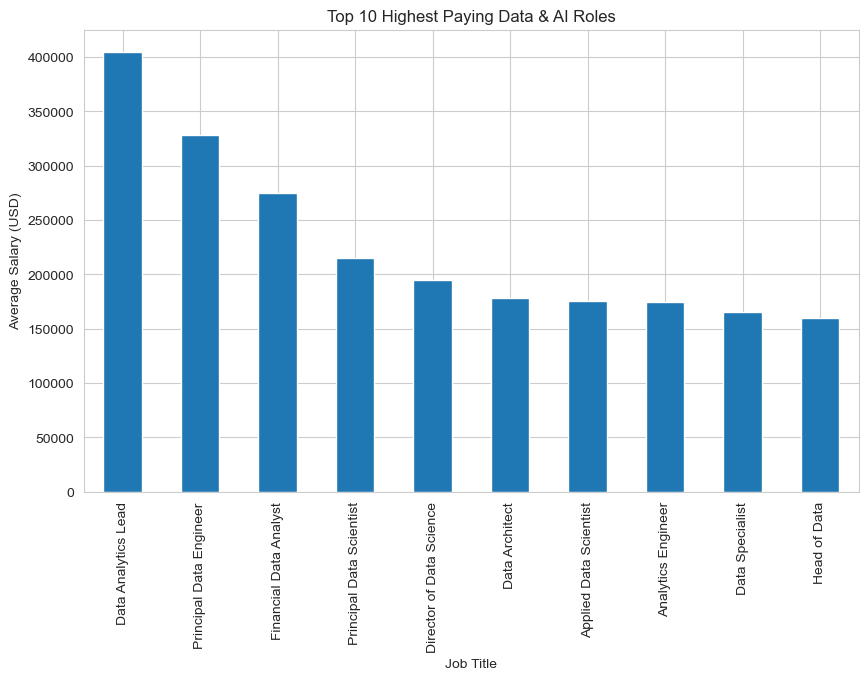

In [21]:
plt.figure(figsize=(10,6))

top_roles.plot(kind="bar")

plt.title("Top 10 Highest Paying Data & AI Roles")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Job Title")

plt.show()

### Interpretation

The analysis of average salaries by job title highlights that leadership and highly specialized technical roles dominate the highest-paying positions.

Roles such as **Data Analytics Lead, Principal Data Engineer, and Financial Data Analyst** appear among the highest-paying positions in the dataset.

These roles typically involve advanced technical expertise, strategic decision-making responsibilities, and leadership in data-driven initiatives within organizations.

#### 10.4 Geographic Distribution of Jobs

This analysis examines which countries have the highest number of Data & AI job opportunities.

In [22]:
top_countries = df["company_location"].value_counts().head(10)

top_countries

US    318
GB     46
CA     28
DE     27
IN     24
FR     15
ES     14
GR     10
JP      6
NL      4
Name: company_location, dtype: int64

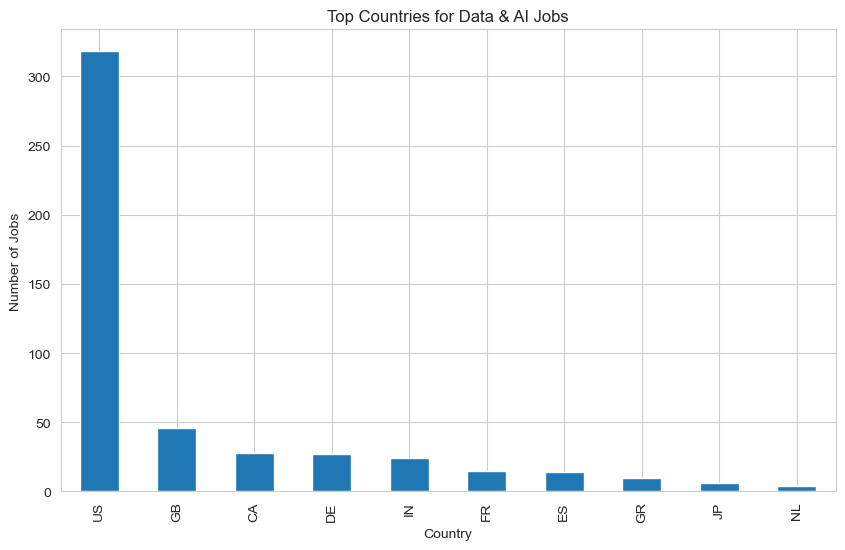

In [23]:
plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top Countries for Data & AI Jobs")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")

plt.show()

### Interpretation

The geographic distribution of jobs reveals a strong concentration of Data and AI roles in the **United States**, which dominates the dataset by a significant margin.

Other countries such as the **United Kingdom, Canada, Germany, and India** also contribute to the global data job market, but their job counts are much lower compared to the US.

This suggests that the United States remains the primary global hub for data science and artificial intelligence employment opportunities.

#### 10.5 Remote Work Distribution

Remote work has become increasingly common in the data industry.

This analysis examines how jobs are distributed across on-site, hybrid, and fully remote work arrangements.

In [24]:
df["remote_type"].value_counts()

Fully Remote    346
On-site         121
Hybrid           98
Name: remote_type, dtype: int64

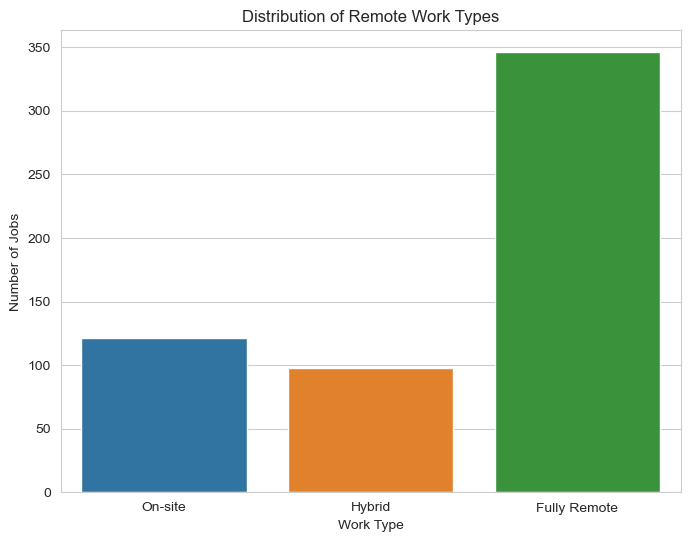

In [25]:
plt.figure(figsize=(8,6))

sns.countplot(x="remote_type", data=df)

plt.title("Distribution of Remote Work Types")
plt.xlabel("Work Type")
plt.ylabel("Number of Jobs")

plt.show()

### Interpretation

The remote work analysis shows that **fully remote positions represent the largest share of jobs in the dataset**, followed by on-site and hybrid roles.

This reflects the digital nature of data and AI roles, where many tasks such as data analysis, machine learning development, and data engineering can be performed remotely.

The high number of remote roles also highlights the increasing global accessibility of data careers.

## 11. Advanced Data Analysis

After performing exploratory analysis, deeper analytical techniques are applied to uncover additional relationships within the dataset.

This section focuses on identifying correlations, geographic salary patterns, and relationships between experience level and remote work.

The following analyses are conducted:

1. Correlation analysis between numerical variables  
2. Salary trends over time  
3. Salary comparison across countries  
4. Relationship between experience level and remote work distribution

### 11.1 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset.

A correlation heatmap is used to visualize how strongly variables such as salary, work year, and remote work ratio are related.

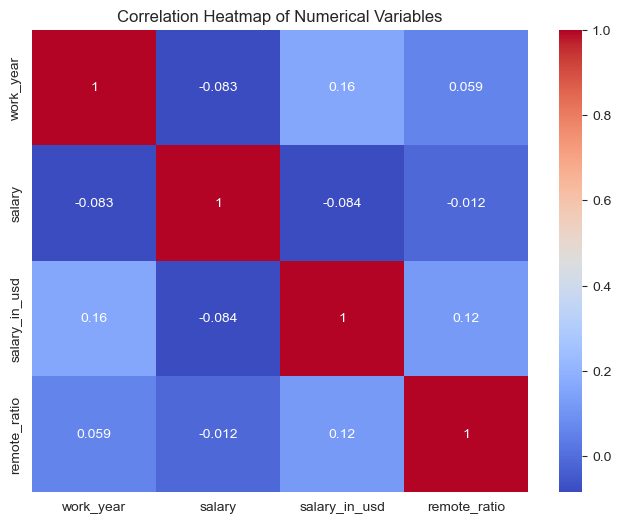

In [26]:
plt.figure(figsize=(8,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

### Interpretation

The correlation heatmap shows the relationships between the numerical variables in the dataset.

The analysis indicates that there is **very weak correlation between salary and the other numerical variables**, including work year and remote work ratio. This suggests that salary levels are not strongly determined by these numerical factors alone.

Instead, salary differences are likely driven by **categorical factors such as job role, experience level, company size, and geographic location**.

The slightly positive relationship between `work_year` and `salary_in_usd` may indicate that salaries have been gradually increasing over time, reflecting the growing demand for data professionals.

### 11.2 Salary Trend Over Time

This analysis examines how average salaries for Data and AI roles have changed over time.

In [27]:
salary_year = df.groupby("work_year")["salary_in_usd"].mean()

salary_year

work_year
2020     95813.000000
2021     99430.413953
2022    123089.097122
Name: salary_in_usd, dtype: float64

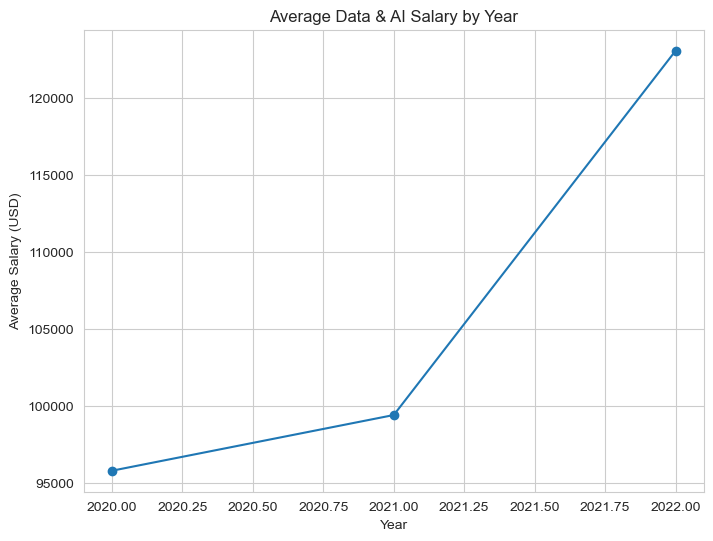

In [28]:
plt.figure(figsize=(8,6))

salary_year.plot(marker="o")

plt.title("Average Data & AI Salary by Year")
plt.xlabel("Year")
plt.ylabel("Average Salary (USD)")

plt.show()

### Interpretation

The salary trend analysis reveals a noticeable increase in the average salary for Data and AI professionals between 2020 and 2022.

Average salaries rose from approximately **$96,000 in 2020 to over $120,000 in 2022**, indicating strong growth in compensation for data-related roles.

This upward trend likely reflects the rapid expansion of data-driven technologies, increased demand for machine learning expertise, and the growing importance of data analytics across industries.

### 11.3 Salary Comparison by Country

This analysis compares average salaries across different countries to identify which regions offer the highest compensation for data professionals.

In [29]:
salary_country = df.groupby("company_location")["salary_in_usd"].mean().sort_values(ascending=False).head(10)

salary_country

company_location
RU    157500.000000
US    144292.993711
NZ    125000.000000
IL    119059.000000
JP    114127.333333
AU    108042.666667
CA    100121.857143
AE    100000.000000
DZ    100000.000000
IQ    100000.000000
Name: salary_in_usd, dtype: float64

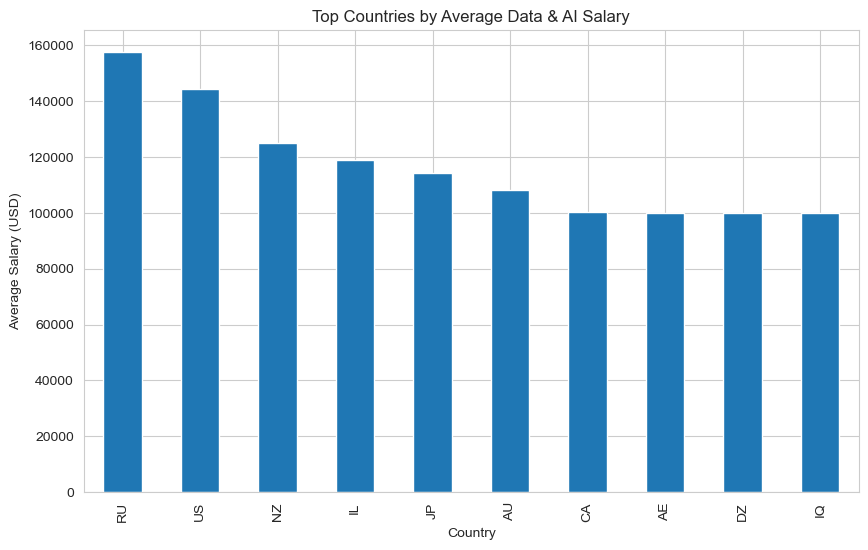

In [30]:
plt.figure(figsize=(10,6))

salary_country.plot(kind="bar")

plt.title("Top Countries by Average Data & AI Salary")
plt.xlabel("Country")
plt.ylabel("Average Salary (USD)")

plt.show()

### Interpretation

The country-level analysis highlights differences in average salary levels across global regions.

Certain countries appear to offer significantly higher compensation for Data and AI roles, which may be influenced by factors such as economic development, technology industry maturity, and demand for advanced data expertise.

Countries with strong technology sectors and higher costs of living tend to provide higher salaries for data professionals.

### 11.4 Experience Level and Remote Work

This analysis examines how remote work opportunities vary across experience levels.

In [31]:
pd.crosstab(df["experience_level"], df["remote_type"])

remote_type,Fully Remote,Hybrid,On-site
experience_level,,,
Entry,49,25,14
Executive,18,5,3
Mid,113,41,54
Senior,166,27,50


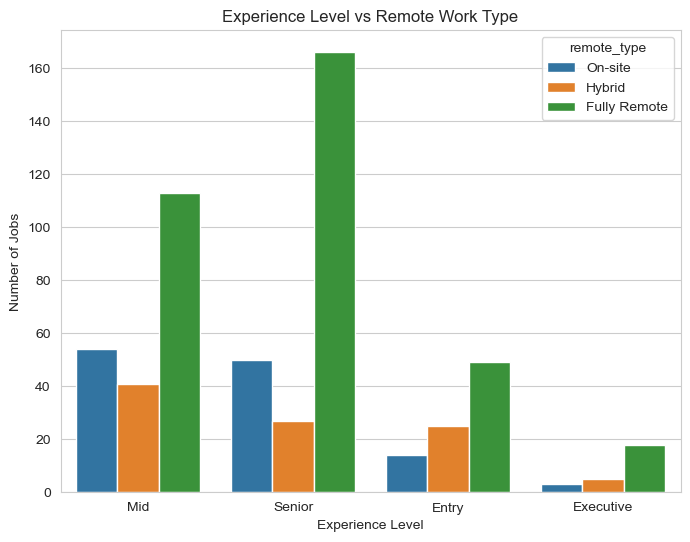

In [32]:
plt.figure(figsize=(8,6))

sns.countplot(x="experience_level", hue="remote_type", data=df)

plt.title("Experience Level vs Remote Work Type")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")

plt.show()

### Interpretation

The relationship between experience level and remote work reveals that remote work opportunities are present across all experience levels.

However, senior and mid-level professionals appear to have greater access to fully remote roles compared to entry-level positions.

This pattern suggests that organizations may offer remote work more frequently to experienced professionals who possess the expertise and autonomy required to work effectively in distributed environments.

## 12. Machine Learning Model – Salary Prediction

After performing exploratory and advanced analysis, a machine learning model is developed to predict salaries for Data and AI professionals.

The objective of this model is to estimate salary levels based on key job characteristics such as:

- experience level
- employment type
- company size
- remote work type
- company location

The machine learning pipeline includes:

1. Feature selection
2. Encoding categorical variables
3. Train-test split
4. Model training
5. Model evaluation

#### 12.1 Feature Selection

In this step, relevant variables are selected as input features for the machine learning model.

The target variable for prediction is **salary_in_usd**, while the remaining selected variables act as predictors.

In [34]:
features = df[[
    "experience_level",
    "employment_type",
    "company_size",
    "remote_type",
    "company_location"
]]

target = df["salary_in_usd"]

#### 12.2 Encoding Categorical Variables

Since the dataset contains categorical variables, they must be converted into numerical representations before training the model.

One-hot encoding is applied to transform categorical features into binary indicator variables.

In [35]:
features_encoded = pd.get_dummies(features, drop_first=True)

features_encoded.head()

,experience_level_Executive,experience_level_Mid,experience_level_Senior,employment_type_FL,employment_type_FT,employment_type_PT,company_size_Medium,company_size_Small,remote_type_Hybrid,remote_type_On-site,...,company_location_PL,company_location_PT,company_location_RO,company_location_RU,company_location_SG,company_location_SI,company_location_TR,company_location_UA,company_location_US,company_location_VN
0,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,1,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


#### 12.3 Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to train the model, while the testing set is used to evaluate model performance.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded,
    target,
    test_size=0.2,
    random_state=42
)

#### 12.4 Model Training

A Linear Regression model is trained to predict salaries based on the selected features.

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

limit_output extension: Maximum message size of 10000 exceeded with 12985 characters

In [38]:
predictions = model.predict(X_test)

#### 12.5 Model Evaluation

The model is evaluated using standard regression metrics.

These include:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R-squared score

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 37192.03984702342
MSE: 3250679231.862026
R2 Score: 0.3233198802988452


#### Interpretation

The machine learning model attempts to estimate salaries based on job characteristics such as experience level, company size, and remote work type.

The evaluation metrics indicate how well the model predicts salary values compared to the actual data. A higher R-squared value suggests that the model explains a larger portion of salary variation.

However, salary prediction is inherently complex because compensation is influenced by many factors including skills, industry, company revenue, and geographic economic conditions.

## 13. Model Comparison

To improve the robustness of the analysis, an additional machine learning model is trained and compared with the Linear Regression model.

Random Forest Regression is used as an alternative model because it can capture complex nonlinear relationships between variables.

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [41]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest MAE:", rf_mae)
print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 35633.20316006182
Random Forest MSE: 3454169646.4524326
Random Forest R2: 0.2809601430619604


### Interpretation

The Random Forest model provides an alternative approach to predicting salaries by capturing nonlinear relationships between variables.

Comparing the performance of the Random Forest model with Linear Regression helps determine which model better explains salary variations in the dataset.

## 14. Conclusion

This project analyzed the global Data and AI job market using data analytics and machine learning techniques.

The analysis revealed several important insights:

• Salaries for Data and AI professionals have increased over time.  
• Experience level plays a major role in determining compensation.  
• Leadership and specialized technical roles tend to command the highest salaries.  
• The United States dominates the dataset as the largest market for data-related roles.  
• Remote work opportunities are widely available across the data industry.

The machine learning models demonstrated that salary prediction is possible using job characteristics, although compensation is influenced by many external factors beyond the dataset.

Overall, the project highlights the evolving structure of the global data labor market and the growing demand for skilled data professionals.

## 15. Future Work

Although this project provides useful insights into the global Data and AI job market, several extensions could further enhance the analysis.

Future research could include:

• Incorporating larger and more recent datasets covering additional years  
• Analyzing specific technical skills mentioned in job descriptions  
• Studying industry-specific salary differences across sectors  
• Applying more advanced machine learning algorithms such as Gradient Boosting or Neural Networks  
• Developing an interactive dashboard for real-time job market intelligence

These extensions would provide a deeper understanding of global demand for data professionals and improve the predictive capabilities of salary models.